# Evaluación — Módulo de Interpolación y Aproximación

**Programación Científica 2026-1 · Universidad Nacional de Colombia**

mbastidaso@unal.edu.co


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)

---

**Integrantes:** (orden alfabético)
- Apellido1, Nombre1: `Bustos, Christian`
- Apellido2, Nombre2: `Toro,Juan`

---

## Instrucciones generales

**Duración:** 1.5 horas

**Recursos permitidos:** internet, LLMs, notebooks del curso. No pueden compartir código ni respuestas con otras parejas.

**Entrega — flujo GitHub obligatorio:**

0. Crear una copia de este archivo que se llama `apellido1_apellido2_evaluacion1.ipynb` en la carpeta EVALUACION y sobre ese archivo se harán todos los resultados/cambios/commits.

1. Crear una rama con el nombre exacto: `apellido1_apellido2_5Junio` (orden alfabético, minúsculas, sin tildes, sin espacios).

2. Trabajen **únicamente sobre esa rama**. Deben hacer **exactamente 3 commits** antes de abrir el PR.

3. Los mensajes de commit deben seguir esta convención y cubrir avance real:
   ```
   init: cedulas, seed y generacion de datos
   add: interpolacion spline y ajuste LS
   add: PCA y analisis escritos
   ```

4. Abran un **Pull Request** de su rama a `main`. En el título del PR escriban: `Evaluación [Apellido1] [Apellido2]`.

⚠️ **Penalizaciones automáticas:**
- Notebook que no ejecuta de principio a fin (`Kernel → Restart & Run All`): −10 pts.
- Menos o más de 3 commits: −5 pts.
- Rama con nombre incorrecto: −5 pts.

---

**Distribución de puntos:**

| Sección | Puntos |
|---|---|
| P0 — Inicialización y datos | 5 |
| P1 — Cuestionario conceptual | 20 |
| P2 — Interpolación B-spline 2D | 30 |
| P3 — Ajuste por mínimos cuadrados | 20 |
| P4 — PCA | 15 |
| GitHub (commits + PR + respuesta) | 10 |
| **Total** | **100** |

---
## P0 — Inicialización (5 pts)

Escriban sus números de cédula en las variables indicadas. **No modifiquen ninguna otra línea de esta sección.** Todos los datos del ejercicio se generan a partir de su semilla.

In [4]:
# TODO P0: reemplacen los ceros con sus ID reales
cedula1 = 1036448414
cedula2 = 1022143298

In [5]:
# 🔒 CELDA DE DATOS — no modificar
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline
from scipy.linalg import svd

assert cedula1 != 0 and cedula2 != 0, "Deben ingresar sus ID en la celda anterior."

seed = int((cedula1 + cedula2) % 1000)
rng  = np.random.default_rng(seed)

# Parámetros de la superficie — dependen de la semilla
alpha = 1.0 + (seed % 7)  * 0.3          # frecuencia en x: entre 1.0 y 2.8
beta  = 1.0 + (seed % 5)  * 0.4          # frecuencia en y: entre 1.0 y 2.6
gamma = 0.10 + (seed % 11) * 0.02        # decaimiento gaussiano: entre 0.10 y 0.30
noise_std = 0.05 + (seed % 13) * 0.01    # ruido: entre 0.05 y 0.17

# Malla gruesa de muestreo (15x15 puntos)
n  = 15
x_raw = np.linspace(-3, 3, n)
y_raw = np.linspace(-3, 3, n)
X_raw, Y_raw = np.meshgrid(x_raw, y_raw, indexing='ij')

# Elevación verdadera + ruido
Z_true = np.sin(alpha * X_raw) * np.cos(beta * Y_raw) * np.exp(-gamma * (X_raw**2 + Y_raw**2))
Z_data = Z_true + rng.normal(0, noise_std, X_raw.shape)

print(f"Semilla: {seed}")
print(f"Parámetros — alpha: {alpha:.2f}, beta: {beta:.2f}, gamma: {gamma:.3f}, ruido: {noise_std:.3f}")
print(f"Malla de datos: {n}x{n} puntos en [-3,3]x[-3,3]")
print(f"Z_data shape: {Z_data.shape}")

Semilla: 712
Parámetros — alpha: 2.50, beta: 1.80, gamma: 0.260, ruido: 0.150
Malla de datos: 15x15 puntos en [-3,3]x[-3,3]
Z_data shape: (15, 15)


---
## P1 — Cuestionario conceptual (20 pts)

Respondan las siguientes preguntas **sin ejecutar código adicional**. Basen sus respuestas en la lectura del bloque de generación de datos de P0.

### P1.1 (7 pts)

La celda de datos genera `Z_data = Z_true + ruido`. Cuando construyan el spline en P2, este va a **interpolar** `Z_data`, no `Z_true`.

**a)** ¿Qué significa que el spline interpole `Z_data` en lugar de ajustar `Z_true`? ¿El spline va a pasar exactamente por los valores de `Z_data`?  
**b)** ¿En qué condición sería preferible usar mínimos cuadrados en lugar del spline para reconstruir la superficie?

**Respuesta P1.1:**

### a)

Que el spline interpole `Z_data` significa que se construye usando los datos medidos, que incluyen ruido. Por lo tanto, el spline pasa exactamente por todos los valores de `Z_data`, pero no necesariamente representa la superficie verdadera `Z_true`.

### b)

Es preferible usar mínimos cuadrados cuando los datos tienen ruido significativo. Este método no pasa exactamente por todos los puntos, sino que busca una aproximación que capture la tendencia general de la superficie y reduzca el efecto del ruido.

### P1.2 (7 pts)

En P3 van a ajustar un plano $z = c_0 + c_1 x + c_2 y$ a los datos usando mínimos cuadrados.

**a)** ¿Cómo se construye la matriz $A$ del sistema $A\mathbf{c} = \mathbf{z}$ para este modelo? Descríbanla en términos de sus columnas.  
**b)** La función verdadera `Z_true` no es un plano. ¿Qué representa entonces el plano ajustado? ¿Qué información útil les da sobre la superficie?

**Respuesta P1.2:**

### a)

Para el modelo

$$
z = c_0 + c_1x + c_2y,
$$

la matriz $A$ se construye con una fila por cada dato $(x_i,y_i)$. Sus columnas son:

- Primera columna: unos (correspondiente a $c_0$).
- Segunda columna: valores de $x_i$ (correspondiente a $c_1$).
- Tercera columna: valores de $y_i$ (correspondiente a $c_2$).

De esta forma, cada fila de $A$ tiene la forma

$$
[1,\; x_i,\; y_i].
$$

### b)

Como la superficie verdadera no es un plano, el plano ajustado no reproduce todos sus detalles. Representa la tendencia general de los datos en toda la región estudiada. Este ajuste permite identificar el comportamiento promedio de la superficie y cómo varía globalmente con respecto a las direcciones $x$ e $y$.

### P1.3 (6 pts)

En P4 van a aplicar PCA a la nube de puntos $(x_i, y_i, z_i)$ formada por los 225 puntos de la malla.

**a)** ¿Por qué es necesario centrar los datos antes de calcular los componentes principales?  
**b)** ¿Qué interpretación geométrica tiene el primer componente principal en el contexto de esta superficie?

**Respuesta P1.3:**

### a)

Es necesario centrar los datos para que PCA analice únicamente la variabilidad de la nube de puntos y no su posición en el espacio. Al restar la media de cada coordenada, los componentes principales describen las direcciones de máxima variación alrededor del centro de los datos.

### b)

El primer componente principal representa la dirección en la que la nube de puntos $(x_i,y_i,z_i)$ presenta la mayor variación. En el contexto de esta superficie, indica la orientación predominante de la forma global de los datos y la dirección a lo largo de la cual la superficie cambia más.

---
**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"
```

---
## P2 — Interpolación B-spline 2D (27 pts)

Usen `RectBivariateSpline` de `scipy.interpolate` para construir un spline bicúbico sobre los datos `(x_raw, y_raw, Z_data)`.

### P2.1 — Construcción y evaluación (15 pts)

Construyan el spline con `kx=3, ky=3` y evalúenlo en una malla fina de **100×100 puntos** en $[-3,3]\times[-3,3]$.

In [6]:
# TODO P2.1: construir el spline bicúbico y evaluar en malla fina

# P2.1: construir el spline bicúbico y evaluar en malla fina
from scipy.interpolate import RectBivariateSpline

# Spline bicúbico (kx=ky=3) sobre la malla gruesa.
# Como X_raw, Y_raw se generaron con indexing='ij', Z_data[i,j] -> (x_raw[i], y_raw[j]),
# que es justo el orden que RectBivariateSpline necesita (sin trasponer).
spline = RectBivariateSpline(x_raw, y_raw, Z_data, kx=3, ky=3)

# Malla fina de 100x100 puntos en [-3,3] x [-3,3]
n_fine = 100
x_fine = np.linspace(-3, 3, n_fine)
y_fine = np.linspace(-3, 3, n_fine)

# Evaluación vectorizada: pasando los vectores, el spline evalúa en el
# producto cartesiano y devuelve una matriz (100, 100) con grid=True (por defecto).
Z_fine = spline(x_fine, y_fine)

# Mallas 2D para graficar (mismo indexing='ij' que P0)
X_fine, Y_fine = np.meshgrid(x_fine, y_fine, indexing='ij')

print(f"Spline bicúbico construido — grados (kx, ky) = {spline.degrees}")
print(f"Malla fina: {n_fine}x{n_fine}  ->  Z_fine.shape = {Z_fine.shape}")
print(f"Rango Z_data: [{Z_data.min():.3f}, {Z_data.max():.3f}]")
print(f"Rango Z_fine: [{Z_fine.min():.3f}, {Z_fine.max():.3f}]")

Spline bicúbico construido — grados (kx, ky) = (3, 3)
Malla fina: 100x100  ->  Z_fine.shape = (100, 100)
Rango Z_data: [-0.933, 0.945]
Rango Z_fine: [-1.055, 1.088]


### P2.2 — Figura comparativa (15 pts)

Produzcan una figura con **dos paneles side-by-side** (`subplot` 1×2):
- Panel izquierdo: `Z_data` en la malla gruesa (superficie en 3D).
- Panel derecho: superficie interpolada por el spline en la malla fina (3D).

Ambos paneles deben tener: colorbar, ejes etiquetados, y usar el **mismo colormap y los mismos límites de color** (`vmin`/`vmax` iguales en ambos).

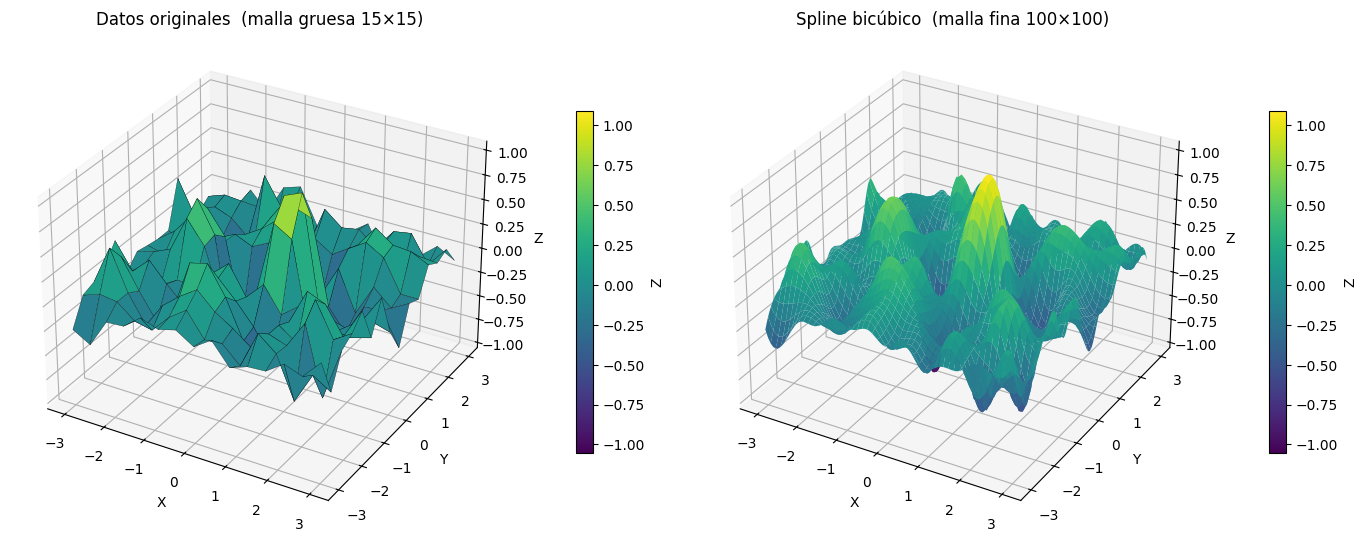

In [7]:
# TODO P2.2: figura comparativa datos vs spline
# Límites de color GLOBALES calculados sobre ambos conjuntos -> escala idéntica.
vmin = min(Z_data.min(), Z_fine.min())
vmax = max(Z_data.max(), Z_fine.max())
cmap = 'viridis'

fig = plt.figure(figsize=(14, 6))

# --- Panel izquierdo: datos originales (malla gruesa 15x15) ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
s1 = ax1.plot_surface(X_raw, Y_raw, Z_data, cmap=cmap, vmin=vmin, vmax=vmax,
                      edgecolor='k', linewidth=0.2, antialiased=True)
ax1.set_title('Datos originales  (malla gruesa 15×15)')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
ax1.set_zlim(vmin, vmax)
fig.colorbar(s1, ax=ax1, shrink=0.6, pad=0.1, label='Z')

# --- Panel derecho: superficie interpolada por el spline (malla fina 100x100) ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
s2 = ax2.plot_surface(X_fine, Y_fine, Z_fine, cmap=cmap, vmin=vmin, vmax=vmax,
                      antialiased=True)
ax2.set_title('Spline bicúbico  (malla fina 100×100)')
ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')
ax2.set_zlim(vmin, vmax)
fig.colorbar(s2, ax=ax2, shrink=0.6, pad=0.1, label='Z')

plt.tight_layout()
plt.show()

---
## P3 — Ajuste por mínimos cuadrados (20 pts)

Ajusten un **plano** $z = c_0 + c_1 x + c_2 y$ a los 225 puntos de la malla usando mínimos cuadrados. Trabajen con los datos ruidosos `Z_data`.

### P3.1 — Ajuste (10 pts)

Construyan la matriz $A$, resuelvan el sistema normal con `np.linalg.lstsq`, e impriman los coeficientes $c_0, c_1, c_2$ con 4 decimales.

In [11]:
# TODO P3.1: construcción de A y ajuste por mínimos cuadrados
# Aplanado vectorizado de las mallas -> vectores de tamaño N=225
x_flat = X_raw.ravel()
y_flat = Y_raw.ravel()
z_flat = Z_data.ravel()
N = x_flat.size                              # 225

# Matriz de diseño del modelo z = c0 + c1*x + c2*y
# Columnas: [unos | x | y]  ->  forma (N, 3)
A = np.column_stack([np.ones(N), x_flat, y_flat])

# Resolución numéricamente estable (vía SVD interna de lstsq)
coef, residuals, rank, svals = np.linalg.lstsq(A, z_flat, rcond=None)
c0, c1, c2 = coef

print(f"N = {N} puntos     A.shape = {A.shape}     rank(A) = {rank}")
print("Coeficientes óptimos del plano  z = c0 + c1·x + c2·y :")
print(f"  c0 = {c0:.4f}")
print(f"  c1 = {c1:.4f}")
print(f"  c2 = {c2:.4f}")

N = 225 puntos     A.shape = (225, 3)     rank(A) = 3
Coeficientes óptimos del plano  z = c0 + c1·x + c2·y :
  c0 = -0.0073
  c1 = -0.0055
  c2 = -0.0026


### P3.2 — Residuos y figura (10 pts)

Calculen el mapa de residuos: $R = Z_{\text{data}} - Z_{\text{plano}}$, donde $Z_{\text{plano}}$ es el plano evaluado en la malla gruesa.

Produzcan una figura con **dos paneles**:
- Panel izquierdo: plano ajustado sobre la malla gruesa, con colorbar y ejes etiquetados.
- Panel derecho: mapa de residuos $R$, con colorbar, ejes etiquetados, y colormap **divergente** centrado en cero.

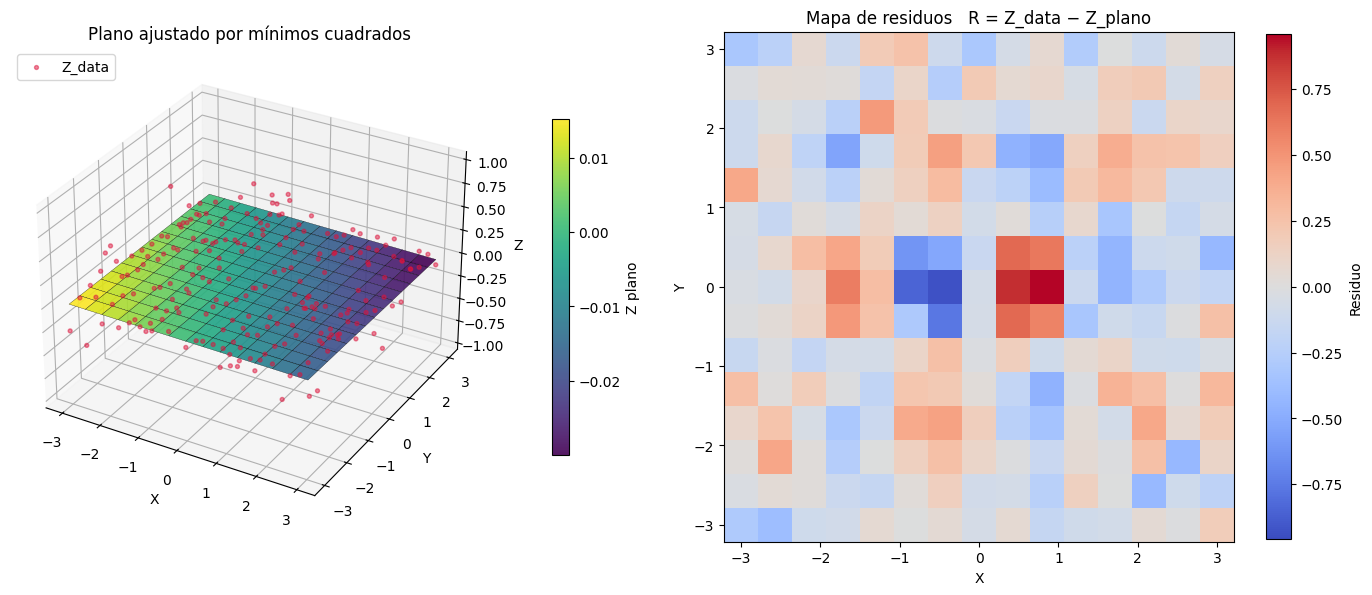

RMSE del ajuste : 0.2605
Residuo máx |R| : 0.9575


In [9]:
# TODO P3.2: plano ajustado y mapa de residuos
# Plano evaluado de forma vectorizada sobre la malla gruesa 15x15
Z_plano = c0 + c1 * X_raw + c2 * Y_raw

# Matriz bidimensional de residuos
R = Z_data - Z_plano

# Límite simétrico para que el colormap divergente quede centrado EXACTO en 0
rmax = np.abs(R).max()

fig = plt.figure(figsize=(14, 6))

# --- Panel izquierdo: plano ajustado en 3D (+ nube de datos) ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
s1 = ax1.plot_surface(X_raw, Y_raw, Z_plano, cmap='viridis', antialiased=True,
                      edgecolor='k', linewidth=0.2, alpha=0.9)
ax1.scatter(X_raw, Y_raw, Z_data, c='crimson', s=8, alpha=0.5, label='Z_data')
ax1.set_title('Plano ajustado por mínimos cuadrados')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
ax1.legend(loc='upper left')
fig.colorbar(s1, ax=ax1, shrink=0.6, pad=0.1, label='Z plano')

# --- Panel derecho: mapa de residuos 2D, divergente centrado en 0 ---
ax2 = fig.add_subplot(1, 2, 2)
pcm = ax2.pcolormesh(X_raw, Y_raw, R, cmap='coolwarm',
                     vmin=-rmax, vmax=rmax, shading='auto')
ax2.set_title('Mapa de residuos   R = Z_data − Z_plano')
ax2.set_xlabel('X'); ax2.set_ylabel('Y')
ax2.set_aspect('equal')
fig.colorbar(pcm, ax=ax2, shrink=0.9, label='Residuo')

plt.tight_layout()
plt.show()

print(f"RMSE del ajuste : {np.sqrt(np.mean(R**2)):.4f}")
print(f"Residuo máx |R| : {rmax:.4f}")

---
**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"

# 3. Segundo commit — después de P2 y P3
git add evaluacion_final_modulo.ipynb
git commit -m "add: interpolacion spline y ajuste LS"
```

---
## P4 — PCA sobre señales sísmicas (15 pts)

Una red de 20 sensores sísmicos registra vibraciones del terreno durante 50 instantes
de tiempo. Las señales están contaminadas con ruido.

In [13]:
omega1 = 1.0 + (seed % 7) * 0.3
omega2 = 1.0 + (seed % 5) * 0.4

m, p = 20, 50
t = np.linspace(0, 2*np.pi, p)

rng2 = np.random.default_rng(seed + 1)
a = rng2.uniform(0.5, 2.0, m)
b = rng2.uniform(0.5, 2.0, m)

X = np.outer(a, np.cos(omega1 * t)) + np.outer(b, np.sin(omega2 * t))
X += rng.normal(0, 0.3, X.shape)

print(f"Señales: {m} sensores x {p} instantes")
print(f"omega1={omega1:.2f}, omega2={omega2:.2f}")

Señales: 20 sensores x 50 instantes
omega1=2.50, omega2=1.80


### P4.1 — Cálculo de componentes principales (7 pts)

Centren las filas de `X` y calculen la SVD con `np.linalg.svd`.

Produzcan una figura con **dos paneles**:
- Panel izquierdo: varianza explicada por cada componente (gráfico de barras).
- Panel derecho: varianza acumulada vs k (puntos + línea), con una línea
  horizontal punteada en el 85%.

Ambos paneles con ejes etiquetados y título.

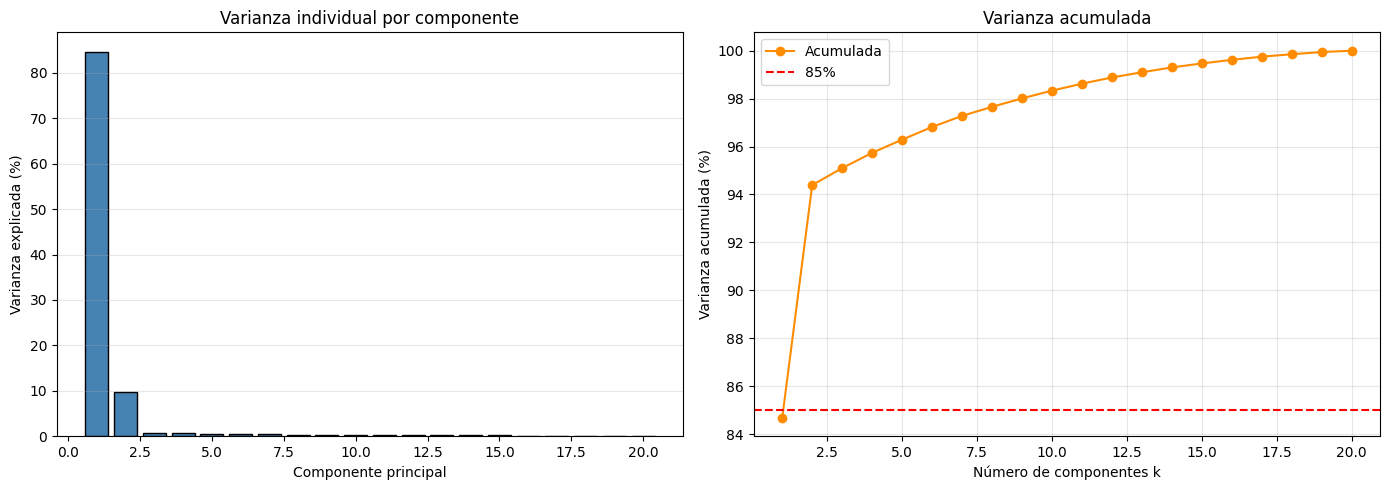

Valores singulares (primeros 5): [34.0763 11.5433  3.118   2.956   2.7445]
Varianza individual  (%): [84.67  9.72  0.71  0.64  0.55]
Varianza acumulada   (%): [84.67 94.39 95.1  95.74 96.29]


In [14]:
# Centrar las filas: cada sensor a media cero sobre el tiempo (vectorizado)
X_centered = X - X.mean(axis=1, keepdims=True)

# SVD económica
U, s, Vt = np.linalg.svd(X_centered, full_matrices=False)

# Varianza explicada a partir de los valores singulares (var_i = s_i^2)
var        = s**2
explained  = var / var.sum()          # individual
cumulative = np.cumsum(explained)     # acumulada
k_comp     = np.arange(1, len(s) + 1)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: varianza individual (barras)
axL.bar(k_comp, explained * 100, color='steelblue', edgecolor='k')
axL.set_xlabel('Componente principal')
axL.set_ylabel('Varianza explicada (%)')
axL.set_title('Varianza individual por componente')
axL.grid(axis='y', alpha=0.3)

# Panel derecho: varianza acumulada (puntos + línea) con referencia al 85%
axR.plot(k_comp, cumulative * 100, 'o-', color='darkorange', label='Acumulada')
axR.axhline(85, ls='--', color='red', label='85%')
axR.set_xlabel('Número de componentes k')
axR.set_ylabel('Varianza acumulada (%)')
axR.set_title('Varianza acumulada')
axR.grid(alpha=0.3)
axR.legend()

plt.tight_layout()
plt.show()

print(f"Valores singulares (primeros 5): {np.round(s[:5], 4)}")
print(f"Varianza individual  (%): {np.round(explained[:5]*100, 2)}")
print(f"Varianza acumulada   (%): {np.round(cumulative[:5]*100, 2)}")

### P4.2 — Proyección en el espacio PCA (8 pts)

Calculen los scores proyectando las 20 señales centradas sobre los primeros k
componentes que explique más del 89% de la varianza (2 o 3).

Produzcan un scatter de los 20 sensores en el espacio de los primeros k PCs:
- Si k=2: scatter PC1 vs PC2, coloreado por índice de sensor, con colorbar
  y etiquetas de sensor en cada punto.
- Si k=3: tres paneles PC1 vs PC2, PC1 vs PC3, PC2 vs PC3.

En todos los casos: ejes etiquetados con el nombre del componente (`"PC1"`, `"PC2"`...),
líneas en cero, grid, título con el porcentaje de varianza acumulada capturada.

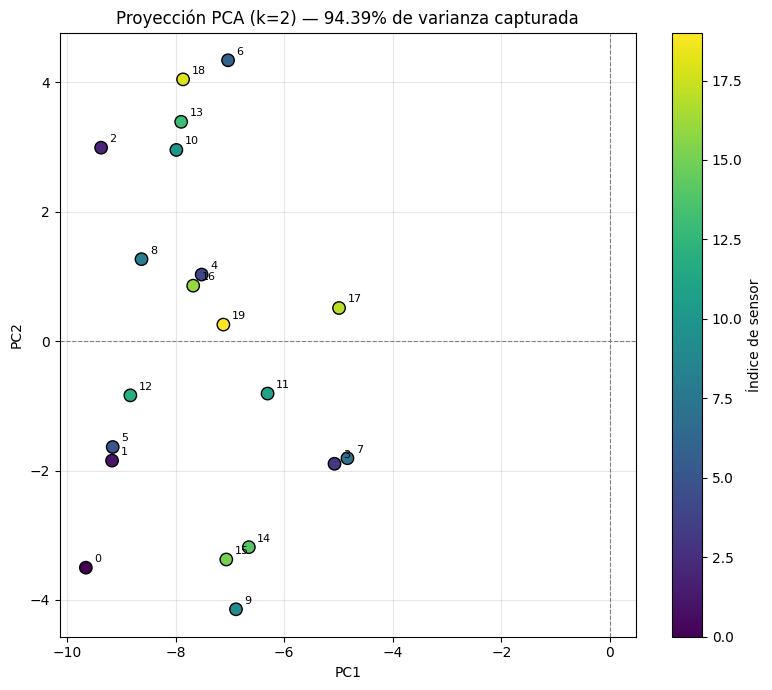

k = 2 componentes superan el 89%  ->  94.39% capturado


In [16]:
# P4.2: k automático para superar 89% y gráfico condicional
threshold = 0.89

# k mínimo cuya varianza acumulada supera el umbral
k = int(np.searchsorted(cumulative, threshold) + 1)
k = int(np.clip(k, 2, 3))            # el enunciado garantiza k = 2 o 3

# Scores: proyección de cada sensor sobre los PCs  (equiv. X_centered @ Vt.T)
scores     = U * s                   # shape (20, 20); columna j -> PC_{j+1}
sensor_idx = np.arange(X.shape[0])
captured   = cumulative[k - 1] * 100 # % exacto capturado por los k componentes

if k == 2:
    # Un único scatter PC1 vs PC2, coloreado por índice de sensor
    fig, ax = plt.subplots(figsize=(8, 7))
    sc = ax.scatter(scores[:, 0], scores[:, 1], c=sensor_idx, cmap='viridis',
                    s=80, edgecolor='k', zorder=3)
    for i in sensor_idx:                      # etiquetas dinámicas de sensor
        ax.annotate(str(i), (scores[i, 0], scores[i, 1]),
                    textcoords='offset points', xytext=(6, 4), fontsize=8)
    ax.axhline(0, color='gray', lw=0.8, ls='--')   # referencia en cero
    ax.axvline(0, color='gray', lw=0.8, ls='--')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.grid(alpha=0.3)
    fig.colorbar(sc, ax=ax, label='Índice de sensor')
    ax.set_title(f'Proyección PCA (k={k}) — {captured:.2f}% de varianza capturada')
    plt.tight_layout()
    plt.show()

elif k == 3:
    # Tres subpaneles cruzados: PC1-PC2, PC1-PC3, PC2-PC3
    pairs = [(0, 1), (0, 2), (1, 2)]
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, (i, j) in zip(axes, pairs):
        sc = ax.scatter(scores[:, i], scores[:, j], c=sensor_idx, cmap='viridis',
                        s=70, edgecolor='k', zorder=3)
        for sidx in sensor_idx:
            ax.annotate(str(sidx), (scores[sidx, i], scores[sidx, j]),
                        textcoords='offset points', xytext=(5, 3), fontsize=7)
        ax.axhline(0, color='gray', lw=0.8, ls='--')
        ax.axvline(0, color='gray', lw=0.8, ls='--')
        ax.set_xlabel(f'PC{i+1}'); ax.set_ylabel(f'PC{j+1}')
        ax.grid(alpha=0.3)
    fig.colorbar(sc, ax=axes, label='Índice de sensor', shrink=0.8)
    fig.suptitle(f'Proyección PCA (k={k}) — {captured:.2f}% de varianza capturada',
                 fontsize=14)
    plt.show()

print(f"k = {k} componentes superan el {threshold*100:.0f}%  ->  {captured:.2f}% capturado")

---
## GitHub (10 pts)

Esta sección se califica directamente desde el PR. No hay celdas adicionales.

**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"

# 3. Segundo commit — después de P2 y P3
git add evaluacion_final_modulo.ipynb
git commit -m "add: interpolacion spline y ajuste LS"

# 4. Tercer commit — después de P4 y todos los análisis escritos
git add evaluacion_final_modulo.ipynb
git commit -m "add: PCA y analisis escritos"

# 5. Push y abrir PR
git push origin apellido1_apellido2_5Junio
```

Luego en GitHub: **New Pull Request** → base: `main` ← compare: `apellido1_apellido2_5Junio`.

Título del PR: `Evaluación [Apellido1] [Apellido2]`
